### VCoC Calculation

In [76]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import pottslab as pl

Read Images

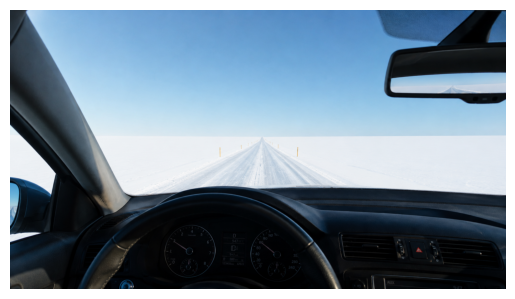

In [77]:
img = cv.imread('pic/4.png')
imgrgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
plt.axis('off')
plt.imshow(imgrgb)
plt.show()

Calculating Potts Segmentation

In [78]:
imgf64 = img.astype(np.float64) / 255.0
seg = pl.min_l2_potts_2d(imgf64, gamma=0.8)
segShow = np.clip(seg * 255, 0, 255).astype(np.uint8)

To CIELab

In [79]:
lab = cv.cvtColor(segShow, cv.COLOR_BGR2Lab)

L, a, b = cv.split(lab)
LStd = L.astype(np.float32) * 100.0 / 255.0
aStd = a.astype(np.float32) - 128
bStd = b.astype(np.float32) - 128

labStd = cv.merge([LStd, aStd, bStd])
labStd

array([[[ 25.490196,  -3.      ,  -9.      ],
        [ 25.490196,  -3.      ,  -9.      ],
        [ 25.490196,  -3.      ,  -9.      ],
        ...,
        [ 34.901962,  -1.      , -26.      ],
        [ 34.901962,  -1.      , -26.      ],
        [ 34.901962,  -1.      , -26.      ]],

       [[ 25.490196,  -3.      ,  -9.      ],
        [ 25.490196,  -3.      ,  -9.      ],
        [ 25.490196,  -3.      ,  -9.      ],
        ...,
        [ 34.901962,  -1.      , -26.      ],
        [ 34.901962,  -1.      , -26.      ],
        [ 34.901962,  -1.      , -26.      ]],

       [[ 25.490196,  -3.      ,  -9.      ],
        [ 25.490196,  -3.      ,  -9.      ],
        [ 25.490196,  -3.      ,  -9.      ],
        ...,
        [ 34.901962,  -1.      , -26.      ],
        [ 34.901962,  -1.      , -26.      ],
        [ 34.901962,  -1.      , -26.      ]],

       ...,

       [[ 22.745098,  -1.      ,   1.      ],
        [ 22.745098,  -1.      ,   1.      ],
        [ 22.745098,  

Calculate CCM

In [80]:
def calculateCCM(block, gamma=14):
     meanColor = block.reshape(-1, 3).mean(axis=0)

     difference = block - meanColor

     E = np.sqrt(difference[:, :, 0] ** 2 + difference[:, :, 1] ** 2 + difference[:, :, 2] ** 2)

     D = 1 - np.exp(-E / gamma)

     alpha = np.std(D)

     if alpha < 1e-8:
          return 0
     
     G = np.exp(-(D ** 2) / (2 * alpha ** 2))

     return np.sum(G)

In [81]:
h, w = labStd.shape[:2]

blocks = [labStd[:h//2, :w//2],
          labStd[:h//2, w//2:],
          labStd[h//2:, :w//2],
          labStd[h//2:, w//2:]
        ]


CCMValues = [calculateCCM(b) for b in blocks]
print(CCMValues)
# for i in range(4):
#     CCMValues.append(calculateCCM(blocks[i]))

VCoC = np.mean(CCMValues)

print(VCoC)

[np.float32(488.02963), np.float32(4.0055647), np.float32(841.2722), np.float32(199.94315)]
383.31262
